# Importing Data

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from datasets import load_dataset
from google.colab import drive

def import_test_variant(path):
    """
    Loads a test set variant based on a path.

    Args:
        path (str): The path of the directory where the test images are stored.

    Returns:
        torchvision.datasets.ImageFolder: A test variant dataset.
    """

    return datasets.ImageFolder(root=path, transform=test_transform)

def transform_train(huggingface):
    """
    Loads a Hugging Face dataset.

    Args:
        huggingface (dict): PIL images from Hugging Face.

    Returns:
        dict: The updated dictionary with a new 'pixel_values' key containing processed Tensors.
    """

    huggingface["pixel_values"] = [train_transform(image.convert("RGB")) for image in huggingface["image"]]
    return huggingface

def collate(images):
    """
    Batches Hugging Face dictionary items into Tensors.

    Args:
        images (list): A list of dictionary items retrieved from the dataset.

    Returns:
        tuple: A pair containing (pixel_values_tensor, labels_tensor).
    """

    pixel_values = torch.stack([image["pixel_values"] for image in images])
    labels = torch.tensor([image["label"] for image in images])
    return pixel_values, labels

# Main dataset
food = load_dataset("ethz/food101")

# Training set
train = food['train'].with_transform(transform_train)
# DO NOT USE food['validation'] for test data, use test_clean instead

# Used to transform training data
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # Random crop and resize to 224x224 px, for robustness
    transforms.RandomHorizontalFlip(), # Random 50% flip, for robustness
    transforms.ToTensor(), # Convert image (0-255) into 0.0-1.0
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard values
])

# Used to transform test data
test_transform = transforms.Compose([
    transforms.Resize(256), # Bigger than 224 so crop ensures food fills image
    transforms.CenterCrop(224), # Same size as the train_transform crop
    transforms.ToTensor(), # Convert image (0-255) into 0.0-1.0
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard values
])

# Connect to Google Drive for test data
drive.mount('/content/drive')

# Put downloaded test_splits into this path in your Google Drive
base_path = '/content/drive/MyDrive/Projects/Food101/test_splits'

# Test variant paths in Google Drive
clean_path = f'{base_path}/clean'
blur_little_path = f'{base_path}/blur_little'
blur_medium_path = f'{base_path}/blur_medium'
downsampled_path = f'{base_path}/downsampled'
masked_path = f'{base_path}/masked'
noise_rotation_path = f'{base_path}/noise_rotation'

# Final test variants
test_clean = import_test_variant(clean_path)
test_blur_little = import_test_variant(blur_little_path)
test_blur_medium = import_test_variant(blur_medium_path)
test_downsampled = import_test_variant(downsampled_path)
test_masked = import_test_variant(masked_path)
test_noise_rotation = import_test_variant(noise_rotation_path)

test_sets = {
    "Clean": test_clean,
    "Blur Little": test_blur_little,
    "Blur Medium": test_blur_medium,
    "Downsampled": test_downsampled,
    "Masked": test_masked,
    "Noise Rotation": test_noise_rotation
}

print("\nData import complete")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

Mounted at /content/drive

Data import complete


# Exploration

In [4]:
print("DATASET SIZES")
print()
print(f"Training: {len(train)}")
print(f"Test (Clean): {len(test_clean)}")
print()
print(f"Test (Blur Little): {len(test_blur_little)}")
print(f"Test (Blur Medium): {len(test_blur_medium)}")
print(f"Test (Downsampled): {len(test_downsampled)}")
print(f"Test (Masked): {len(test_masked)}")
print(f"Test (Noise Rotation): {len(test_noise_rotation)}")

DATASET SIZES

Training: 75750
Test (Clean): 25250

Test (Blur Little): 25250
Test (Blur Medium): 25250
Test (Downsampled): 25250
Test (Masked): 25250
Test (Noise Rotation): 25250


In [5]:
food_classes = test_clean.classes

for i in range(0, len(food_classes), 5):
    print(', '.join(food_classes[i : i + 5]))

apple_pie, baby_back_ribs, baklava, beef_carpaccio, beef_tartare
beet_salad, beignets, bibimbap, bread_pudding, breakfast_burrito
bruschetta, caesar_salad, cannoli, caprese_salad, carrot_cake
ceviche, cheese_plate, cheesecake, chicken_curry, chicken_quesadilla
chicken_wings, chocolate_cake, chocolate_mousse, churros, clam_chowder
club_sandwich, crab_cakes, creme_brulee, croque_madame, cup_cakes
deviled_eggs, donuts, dumplings, edamame, eggs_benedict
escargots, falafel, filet_mignon, fish_and_chips, foie_gras
french_fries, french_onion_soup, french_toast, fried_calamari, fried_rice
frozen_yogurt, garlic_bread, gnocchi, greek_salad, grilled_cheese_sandwich
grilled_salmon, guacamole, gyoza, hamburger, hot_and_sour_soup
hot_dog, huevos_rancheros, hummus, ice_cream, lasagna
lobster_bisque, lobster_roll_sandwich, macaroni_and_cheese, macarons, miso_soup
mussels, nachos, omelette, onion_rings, oysters
pad_thai, paella, pancakes, panna_cotta, peking_duck
pho, pizza, pork_chop, poutine, prime_r

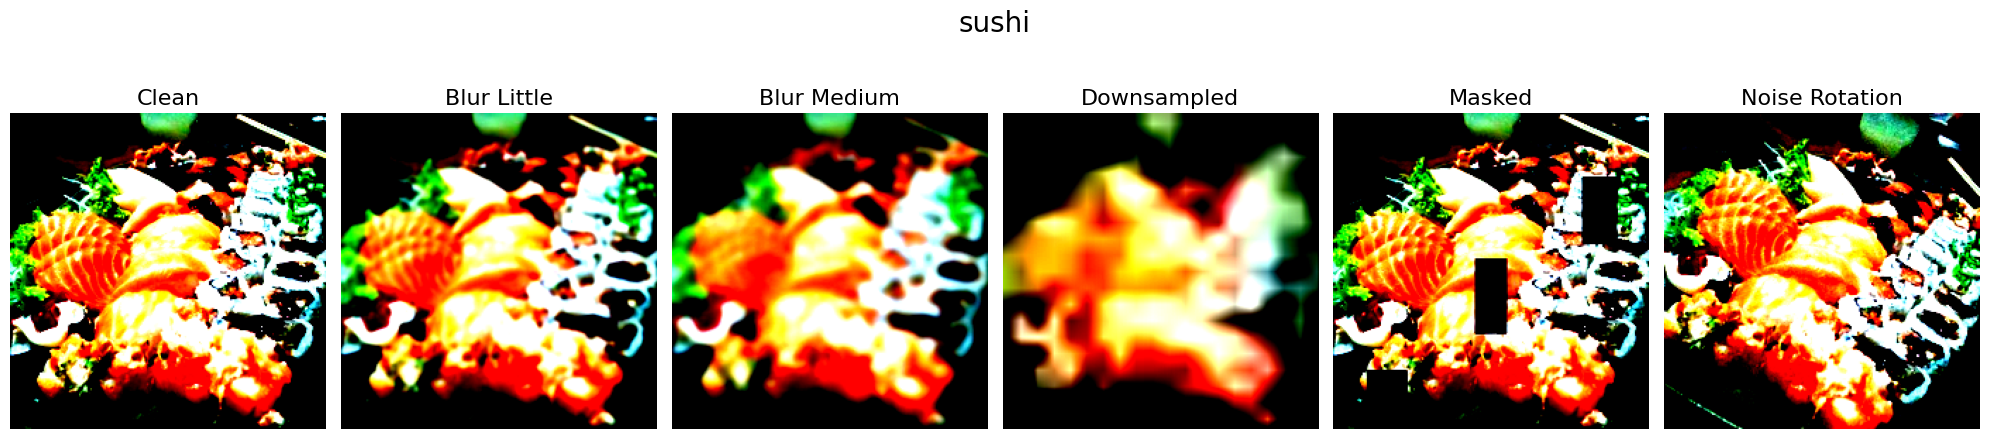

In [6]:
"""
This block of code shows all variants of a random test image (after applying transformer).
"""

import matplotlib.pyplot as plt
import numpy as np
import random

# Getting random test index and the assocoiated class name
random_idx = random.randint(0, len(test_sets["Clean"]) - 1)
_, label_idx = test_sets["Clean"][random_idx]
class_name = test_sets["Clean"].classes[label_idx]

# Plotting
fig, axes = plt.subplots(1, len(test_sets), figsize=(20, 5))

for i, (name, test_set) in enumerate(test_sets.items()):

    # Tensor to image
    img_tensor, _ = test_set[random_idx]
    img = img_tensor.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    # Adding image for variant
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=16)
    axes[i].axis('off')

fig.suptitle(f"{class_name}", fontsize=20)
plt.tight_layout()
plt.show()

# Backbone

In [7]:
import torch.nn as nn
from torchvision import models

# Number of classes of food in the dataset
num_classes = len(food_classes)

# ResNet18
resnet = models.resnet18(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_res = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs_res, num_classes)

# EfficientNetV2-S
effnet = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_eff = effnet.classifier[1].in_features
effnet.classifier[1] = nn.Linear(num_ftrs_eff, num_classes)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 90.3MB/s]


# Linear Probing (Baseline)

In [8]:
import copy

def freeze_all_layers(model):
    """
    Freezes all weights and biases in the neural network.
    Used to establish baseline models.

    Args:
        model (torch.nn.Module): The model whose layers need to be frozen.

    Returns:
        None: The frozen model.
    """

    for param in model.parameters():
        param.requires_grad = False

# ResNet18 Baseline
resnet_baseline = copy.deepcopy(resnet)
freeze_all_layers(resnet_baseline)
# Unfreeze last layer
resnet_baseline.fc.weight.requires_grad = True
resnet_baseline.fc.bias.requires_grad = True

# EfficientNetV2-S Baseline
effnet_baseline = copy.deepcopy(effnet)
freeze_all_layers(effnet_baseline)
# Unfreeze last layer
effnet_baseline.classifier[1].weight.requires_grad = True
effnet_baseline.classifier[1].bias.requires_grad = True

In [9]:
# cuda is GPU, CPU is too slow
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [8]:
BATCH_SIZE = 512
train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate, num_workers=2)

def train_model(model, optimizer):
    """
    Executes the full training and validation pipeline for a model.
    Iterates through 5 epochs, performing a training pass followed by a validation pass in each.
    CrossEntropyLoss is used as the loss function.

    Args:
        model (torch.nn.Module): The model to be trained.
        optimizer (torch.optim.Optimizer): The algorithm responsible for updating model weights.

    Returns:
        tuple: Four lists (train_acc, valid_acc, train_loss, valid_loss)
    """

    model.to(device) # Transfer model to GPU/CPU

    n_epochs = 5 # Number of epochs
    loss_function = nn.CrossEntropyLoss() # Loss function

    for epoch in range(n_epochs):

        model.train() # Put model into training mode

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = loss_function(output, target)
            loss.backward()
            optimizer.step()

        print(f'Epoch {epoch+1}/{n_epochs}')

    print()

In [9]:
model_path = '/content/drive/MyDrive/Projects/Food101/models/'

resnet_baseline.to(device) # resnet_baseline to GPU/CPU
optimizer_resnet = torch.optim.Adam(resnet_baseline.parameters()) # Define optimizer
train_acc_res_base, train_loss_res_base = train_model(resnet_baseline, optimizer_resnet) # Training model
torch.save(resnet_baseline.state_dict(), model_path + 'resnet_baseline.pth') # Save model

effnet_baseline.to(device) # effnet_baseline to GPU/CPU
optimizer_effnet = torch.optim.Adam(effnet_baseline.parameters()) # Define optimizer
train_model(effnet_baseline, optimizer_effnet) # Training model
torch.save(effnet_baseline.state_dict(), model_path + 'effnet_baseline.pth') # Save model

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/5:
	Train Loss: 3.439 | Train Accuracy: 0.267


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 2/5:
	Train Loss: 2.564 | Train Accuracy: 0.414


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch 3/5:
	Train Loss: 2.572 | Train Accuracy: 0.401


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 4/5:
	Train Loss: 2.483 | Train Accuracy: 0.412


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 5/5:
	Train Loss: 2.436 | Train Accuracy: 0.422



# Model Evaluation

In [10]:
# Add any models you create
models_to_evaluate = {
    "resnet_baseline": resnet_baseline,
    "effnet_baseline": effnet_baseline
}

In [ ]:
import pandas as pd
from torch.utils.data import Subset

def evaluate(model, dataset):
    """
    Evaluates the accuracy of a model on a dataset. This function iterates
    through the dataset in batches, performs a forward pass, and calculates the
    percentage of correctly classified images.

    Args:
        model (torch.nn.Module): The model to evaluate.
        dataset (torch.utils.data.Dataset): Dataset of images and labels.

    Returns:
        float: Accuracy between 0 and 1.
    """

    model.eval() # Put model into evaluation mode

    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct/total

model_accuracies = []

# Determining accuracy for each model for each test variant
for model_name, model in models_to_evaluate.items():

    model.to(device)
    model.eval()

    for set_name, test_set in test_sets.items():

        accuracy = evaluate(model, test_set)

        model_accuracies.append({
            "Model": model_name,
            "Dataset": set_name,
            "Accuracy": accuracy
        })

        print(f"Processed {model_name} on the {set_name} test set, accuracy is {round(accuracy, 3)}")

In [ ]:
model_evaluations = pd.DataFrame(model_accuracies)

# Collect accuracies of each model with the clean test set
clean_accuracies = {}
for model in model_evaluations.Model.unique():
    clean_accuracy = model_evaluations.query("Model == @model & Dataset == 'Clean'").Accuracy.item()
    clean_accuracies.update({model: clean_accuracy})

# Calculate robustness
model_evaluations["Robustness"] = model_evaluations.apply(
    lambda row: row["Accuracy"] / clean_accuracies.get(row["Model"], 1), axis=1
)

model_evaluations

,Model,Dataset,Accuracy,Robustness
0,resnet_baseline,Clean,0.011168,1.000000
1,resnet_baseline,Blur Little,0.010693,0.957447
2,resnet_baseline,Blur Medium,0.010337,0.925532
3,resnet_baseline,Downsampled,0.010851,0.971631
4,resnet_baseline,Masked,0.009861,0.882979
5,resnet_baseline,Noise Rotation,0.010772,0.964539
6,effnet_baseline,Clean,0.009941,1.000000
7,effnet_baseline,Blur Little,0.007921,0.796813
8,effnet_baseline,Blur Medium,0.007644,0.768924
9,effnet_baseline,Downsampled,0.008000,0.804781


In [ ]:
# Filter out the Clean rows, variants only
model_evaluations_variants = model_evaluations.query("Dataset != 'Clean'")

# Calculate mean variant Accuracy and Robustness for each Model
variant_sumamary = model_evaluations_variants.groupby("Model")[["Accuracy", "Robustness"]].mean().reset_index()

# Rename columns to be more accurate
variant_sumamary.columns = ["Model", "Avg_Variant_Accuracy", "Avg_Variant_Robustness"]

variant_sumamary

,Model,Avg_Variant_Accuracy,Avg_Variant_Robustness
0,effnet_baseline,0.008935,0.898805
1,resnet_baseline,0.010503,0.940426
